In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
sys.path.append('..')
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06


In [3]:
num_samples = 5000

scale = 1

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 274.16760284403034
T/d 0.003647403958843687
RRKM (tau_beta) 0.02291731496355531
RRKM (s) 2.450442269800038e-08


In [38]:
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [34]:
hbar = 1
std_k = 0.1 / 3
std_x = 1 / std_k
print(std_x)
x0 = 200
print(x0)
k0 = 0.1
print(temp)
print(k0)
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

30.0
200
1.0
0.1
1000.0


(999,)


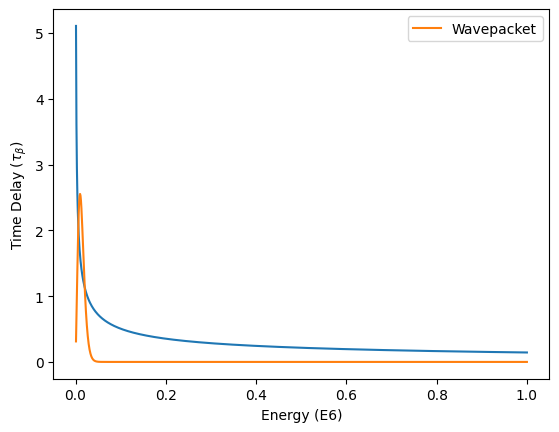

In [39]:
energy_grid = np.linspace(0, 1, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2, label="Wavepacket")
# plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
# plt.savefig("gif_wavepacket.pdf")
plt.show()

In [40]:
xs = np.linspace(-400, 0, 10001)
dx = xs[1] - xs[0]

ps = np.linspace(k0 - 4 * std_k, k0 + 4 * std_k, 20001)
dp = ps[1] - ps[0]
print(dp)
ps = ps.reshape((len(ps), 1))

1.3333333333330477e-05


In [41]:
fluxes = []
fluxes_nores = []

r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
psi1 = []

incoming_envelope = gaussian_envelope(ps) / np.sqrt(2 * np.pi) * np.exp(1j * ps * xs)
outgoing_envelope = gaussian_envelope(ps) / np.sqrt(2 * np.pi) * np.exp(-1j * ps * xs)

In [44]:
import pickle 
from tqdm import tqdm

distances = []
totals = []

for i in tqdm(range(1000)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    
    r2 = lambda k : np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))

    psi2 = []
    reflected_envelope_2 = r2(ps) * outgoing_envelope
    total_envelope_2 = incoming_envelope + reflected_envelope_2
        
    wave2 = np.sum(total_envelope_2, axis=0) * dp

    total2 = np.sum(np.abs(wave2) ** 2).item()
    totals.append(total2)

    x2 = np.sum(np.abs(wave2) ** 2 * xs) / total2

    distances.append(x2.item())

with open("sparse_wavepacket_T=0.01.pkl", "wb") as f:
    pickle.dump(distances, f)

100%|██████████| 1000/1000 [14:46<00:00,  1.13it/s]


In [50]:
with open("sparse_wavepacket_T=1.pkl", "rb") as f:
    distances = pickle.load(f)

In [48]:
print(totals)
print(distances)

[25.00479170296258, 25.004362058784416, 25.004423307091542, 25.00514688437463, 25.005261739444812, 25.004658126613503, 25.00398910029086, 25.004169908808645, 25.004707720985287, 25.004131342728215, 25.005035247275078, 25.004686507202095, 25.004512072391723, 25.00398173969147, 25.004597212084686, 25.004395256453325, 25.005069254645974, 25.00479009686916, 25.003979513743033, 25.004655075626662, 25.0046303709073, 25.0052826712614, 25.004739224545304, 25.004863506427434, 25.003297601853845, 25.003783703319243, 25.003283520974854, 25.004454756449626, 25.004644514263664, 25.00273172130977, 25.004690941562917, 25.004452769594252, 25.004817406209934, 25.004197801052978, 25.00449524457161, 25.003970875689504, 25.004872359902016, 25.007527191135768, 25.00711753908644, 25.004993203930155, 25.005525810087683, 25.00440554949204, 25.004279184285583, 25.0061492110121, 25.006066043038423, 25.0044032454765, 25.00482866945172, 25.006227254825397, 25.004799140450455, 25.003716703278826, 25.00414408162846

161.25312261488952


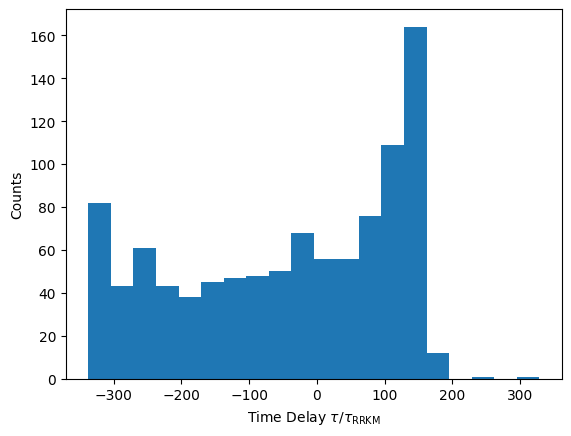

In [51]:
diff_dist = -x0 - np.array(distances) 
rrkm_c6 = 2 * np.pi / mean_spacing 

plt.hist(diff_dist.get() / 2 / k0 / rrkm_c6, bins=20)
plt.xlabel(r"Time Delay $\tau / \tau_{\text{RRKM}}$")
plt.ylabel("Counts")
print(np.std(np.array(diff_dist.get() / 2 / k0 / rrkm_c6).get()))
plt.savefig("dense_wavepacket.pdf")
plt.show()